# Coding Assignment 2: Exploratory Data Analysis on Diabetes Dataset

## Background
Diabetes is one of the most prevalent chronic diseases and creates significant burdens on healthcare systems. The **Diabetes 130-US hospitals dataset** contains over **100,000 records** of hospital admissions for diabetic patients across **130 U.S. hospitals (1999–2008)**. It includes more than **50 attributes**, covering demographics, admission details, diagnoses, lab results, medications, and hospital outcomes.  

Like many real-world healthcare datasets, it presents challenges such as missing values, categorical codes (ICD-9 diagnoses, drug prescriptions), imbalances in outcome variables (e.g., readmission), and inconsistent data formats. Conducting an in-depth **Exploratory Data Analysis (EDA)** will help uncover insights into patient demographics, treatment outcomes, and factors influencing readmission rates.  

---

## Objectives
The goal of this assignment is to conduct a comprehensive **qualitative and quantitative EDA** of the Diabetes dataset. You will:  

- **Understand** the dataset structure, including variables, data types, and overall composition.  
- **Detect and address** data quality issues, such as missing values, duplicates, and inconsistent categories.  
- **Conduct univariate, bivariate, and multivariate analysis** using both qualitative and quantitative EDA, supported by visualization techniques (bar charts, count plots, stacked charts, heatmaps) and statistical methods (descriptive statistics, distribution analysis, and exploration of variable relationships).  
- **Visualize** patterns and correlations to uncover key insights and trends.  

---

## Submission Instructions
- This is an **individual assignment** and carries **5% of the total marks** of this course. 
- You should not discuss your progress or solutions with anyone else.  
- Use this **template Jupyter Notebook and dataset** for your work.  

At the beginning of the notebook, clearly state:  
1. **Your Name and Roll Number**  
2. **Python environment details** (version, libraries used).  
3. Whether you are running locally or on **Google Colab** (*preferred, to ensure all students work in a consistent environment*).  

Additional guidelines:  
- Ensure that your notebook is **fully reproducible**: every cell must run sequentially without errors to regenerate the results.  
- Submit a **single completed notebook file (.ipynb)** before the deadline.  

---


## Dataset Source
- Source of Data : https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
- It represents **hospital admissions of diabetic patients** across 130 U.S. hospitals from 1999 to 2008.
- Read the **Variables Table** in the link above, which provides details of individual variables such as type, role, and description.

##  Dataset Overview - "Diabetes_dataset.csv"
- **Number of records:** ~101,766 hospital admissions  
- **Number of features:** 53  
- **Unit of analysis:** Each row represents **one hospital admission** for a patient (a patient can have multiple admissions).  
- **Target variable (Goal):** Predict whether a patient is **readmitted within 30 days** of discharge.  

###  Key Features with Mappings
- **Admission Type**: `admission_type_id` → mapped to `admission_type_desc`  
- **Discharge Disposition**: `discharge_disposition_id` → mapped to `discharge_desc`  
- **Admission Source**: `admission_source_id` → mapped to `admission_source_desc`  

---

##  Important Notes
- **Missing values:** Several features contain missing values, often recorded as `"?"` (not as `NaN`).   
- **ID columns:** Both numeric IDs and their human-readable descriptions are included after merging. IDs may be useful for re-checking or remapping, while descriptions are helpful for analysis.  


**Note:** Do not just run plots — write down **interpretations** of your findings.  
The goal is to practice *thinking about the data*, not just generating charts.


# 📌 Preamble: Environment Details

Before starting the assignment, please fill in the following:

- **Name**: SWAPNIL TRIVEDI 
- **Roll Number**:  13-19-01-19-52-24-1-24723
- **Environment**: Local Machine 

Run the code cell below to print your Python and library versions.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from ydata_profiling import ProfileReport

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)

%matplotlib inline

Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Pandas version: 2.3.2
NumPy version: 1.26.4
Matplotlib version: 3.10.0
Seaborn version: 0.13.2


## Load and Inspect the dataset structure 

In [2]:
input_dataset_path = './Diabetes_dataset.csv'
data=pd.read_csv(input_dataset_path)
print("Dataset loaded successfully with shape:", data.shape)
# print("First few rows of the dataset:")
# print(data.head(5))

Dataset loaded successfully with shape: (101766, 53)


In [3]:
## data exploration types of data onjects and their info
print("\nDataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-

In [4]:
# statistical summary of the dataset
print("\nStatistical Summary of the Dataset:")
data.describe()


Statistical Summary of the Dataset:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [5]:
# Summarize the dataset
summary = {
    "Number of rows": len(data),
    "Number of columns": len(data.columns),
    "Column names": data.columns.tolist(),
    "Data types": data.dtypes.to_dict(),
    "Missing values per column": data.isnull().sum().to_dict(),
    "Unique values per column": data.nunique().to_dict(),
}
print("\nDataset Summary:")
print("\t --> Number of rows:", summary["Number of rows"])
print("\t --> Number of columns:", summary["Number of columns"])
print("Column names:", summary["Column names"])
print("Data types:")
## group data types
data_types = {}
for col, dtype in summary["Data types"].items():
    dtype_str = str(dtype)
    if dtype_str not in data_types:
        data_types[dtype_str] = []
    data_types[dtype_str].append(col)
for dtype, cols in data_types.items():
    print(f"\t --> {dtype}: {cols}")
print("Missing values per column")
for col, missing in summary["Missing values per column"].items():
    if missing > 0:
        print(f"\t --> {col}: {missing}")


Dataset Summary:
	 --> Number of rows: 101766
	 --> Number of columns: 53
Column names: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type_desc', 'discharge_desc', 'admission_source_desc']
Data types:
	 --> int64: ['

### A lot of categorical variables are present which needs to be encoded and explored, some of them needs to be converted into numerical variables itself, example age is object but should be converted into numerical variable.


#### Using Ydata for reporting

In [6]:
profile = ProfileReport(data, title="Diabetes Dataset Raw- EDA Report")
profile.to_file("diabetes_data_eda_raw_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 53/53 [00:04<00:00, 10.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Data Pre-processing (cleaning, transformation, handling missing values, etc.)

In [7]:
## drop duplicates if any
initial_shape = data.shape
data.drop_duplicates(inplace=True)
if data.shape != initial_shape:
    print(f"Dropped {initial_shape[0] - data.shape[0]} duplicate rows. New shape: {data.shape}")
else:
    print("No duplicate rows found.")

No duplicate rows found.


##### Per column cleaning and transformation

In [8]:
### list of numerical columns
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumerical columns:", numerical_cols)
print("Statistical summary of numerical columns:")
print(data[numerical_cols].info())


Numerical columns: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Statistical summary of numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   admission_type_id         101766 non-null  int64
 3   discharge_disposition_id  101766 non-null  int64
 4   admission_source_id       101766 non-null  int64
 5   time_in_hospital          101766 non-null  int64
 6   num_lab_procedures        101766 non-null  int64
 7   num_procedures            101766 non-null  int64
 8   num_medications   

# Analysis of Numerical columns

- Total numerical columns: 13, including identifiers, admission details, and clinical measures.
- No missing values: All numerical columns are complete for all 101,766 records.
- Column types: All are integers (int64), suitable for counts and coded categories.
- Identifiers: encounter_id and patient_nbr are unique IDs, not useful for statistical analysis but important for tracking.
- Admission and discharge codes: Columns like admission_type_id, discharge_disposition_id, and admission_source_id are categorical codes and should be mapped to their descriptions for interpretation.
- Clinical measures: Columns such as time_in_hospital, num_lab_procedures, num_procedures, num_medications, and various number_* columns provide quantitative information about patient care and hospital resource use.
- Data quality: No duplicates or missing data in these columns, making them reliable for further analysis.

In [9]:
# statistical summary of numerical columns
print("\nStatistical Summary of Numerical Columns:")
print(data[numerical_cols].describe())


Statistical Summary of Numerical Columns:
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%     

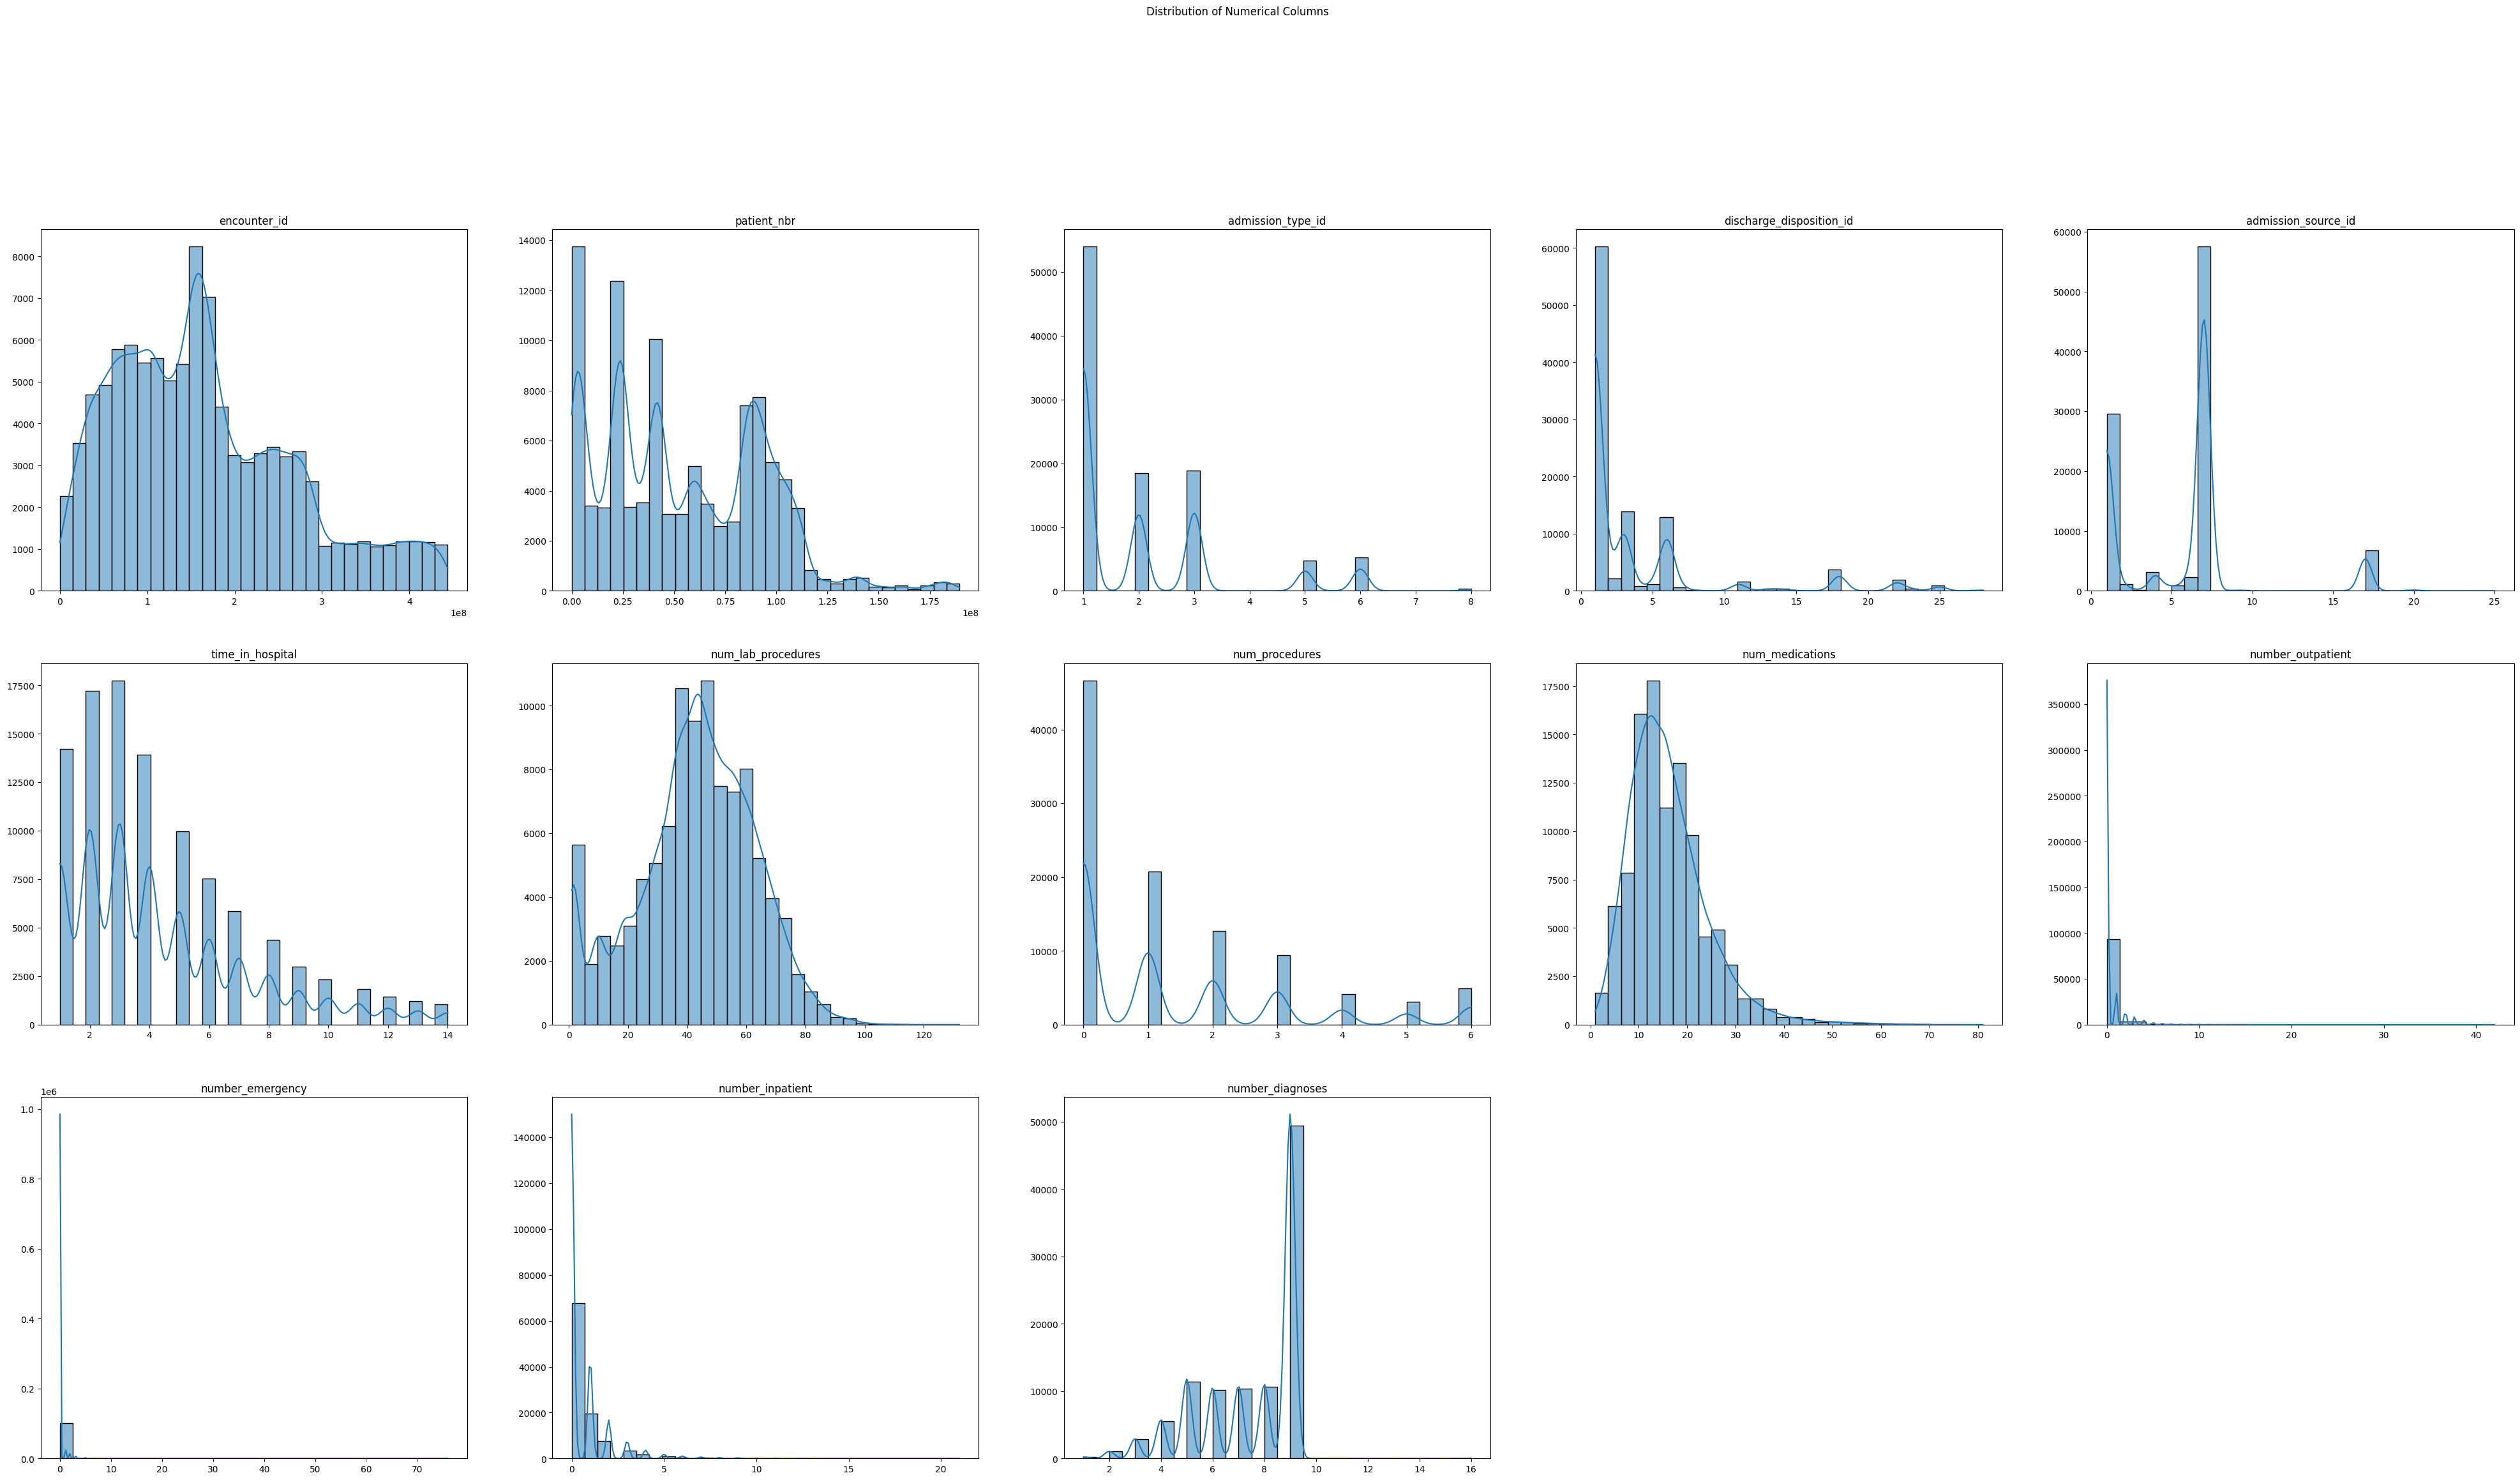

In [10]:
plt.figure(figsize=(50,25))
plt.tight_layout()
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 5, i + 1)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('Distribution of Numerical Columns', y=1.02)
plt.show()

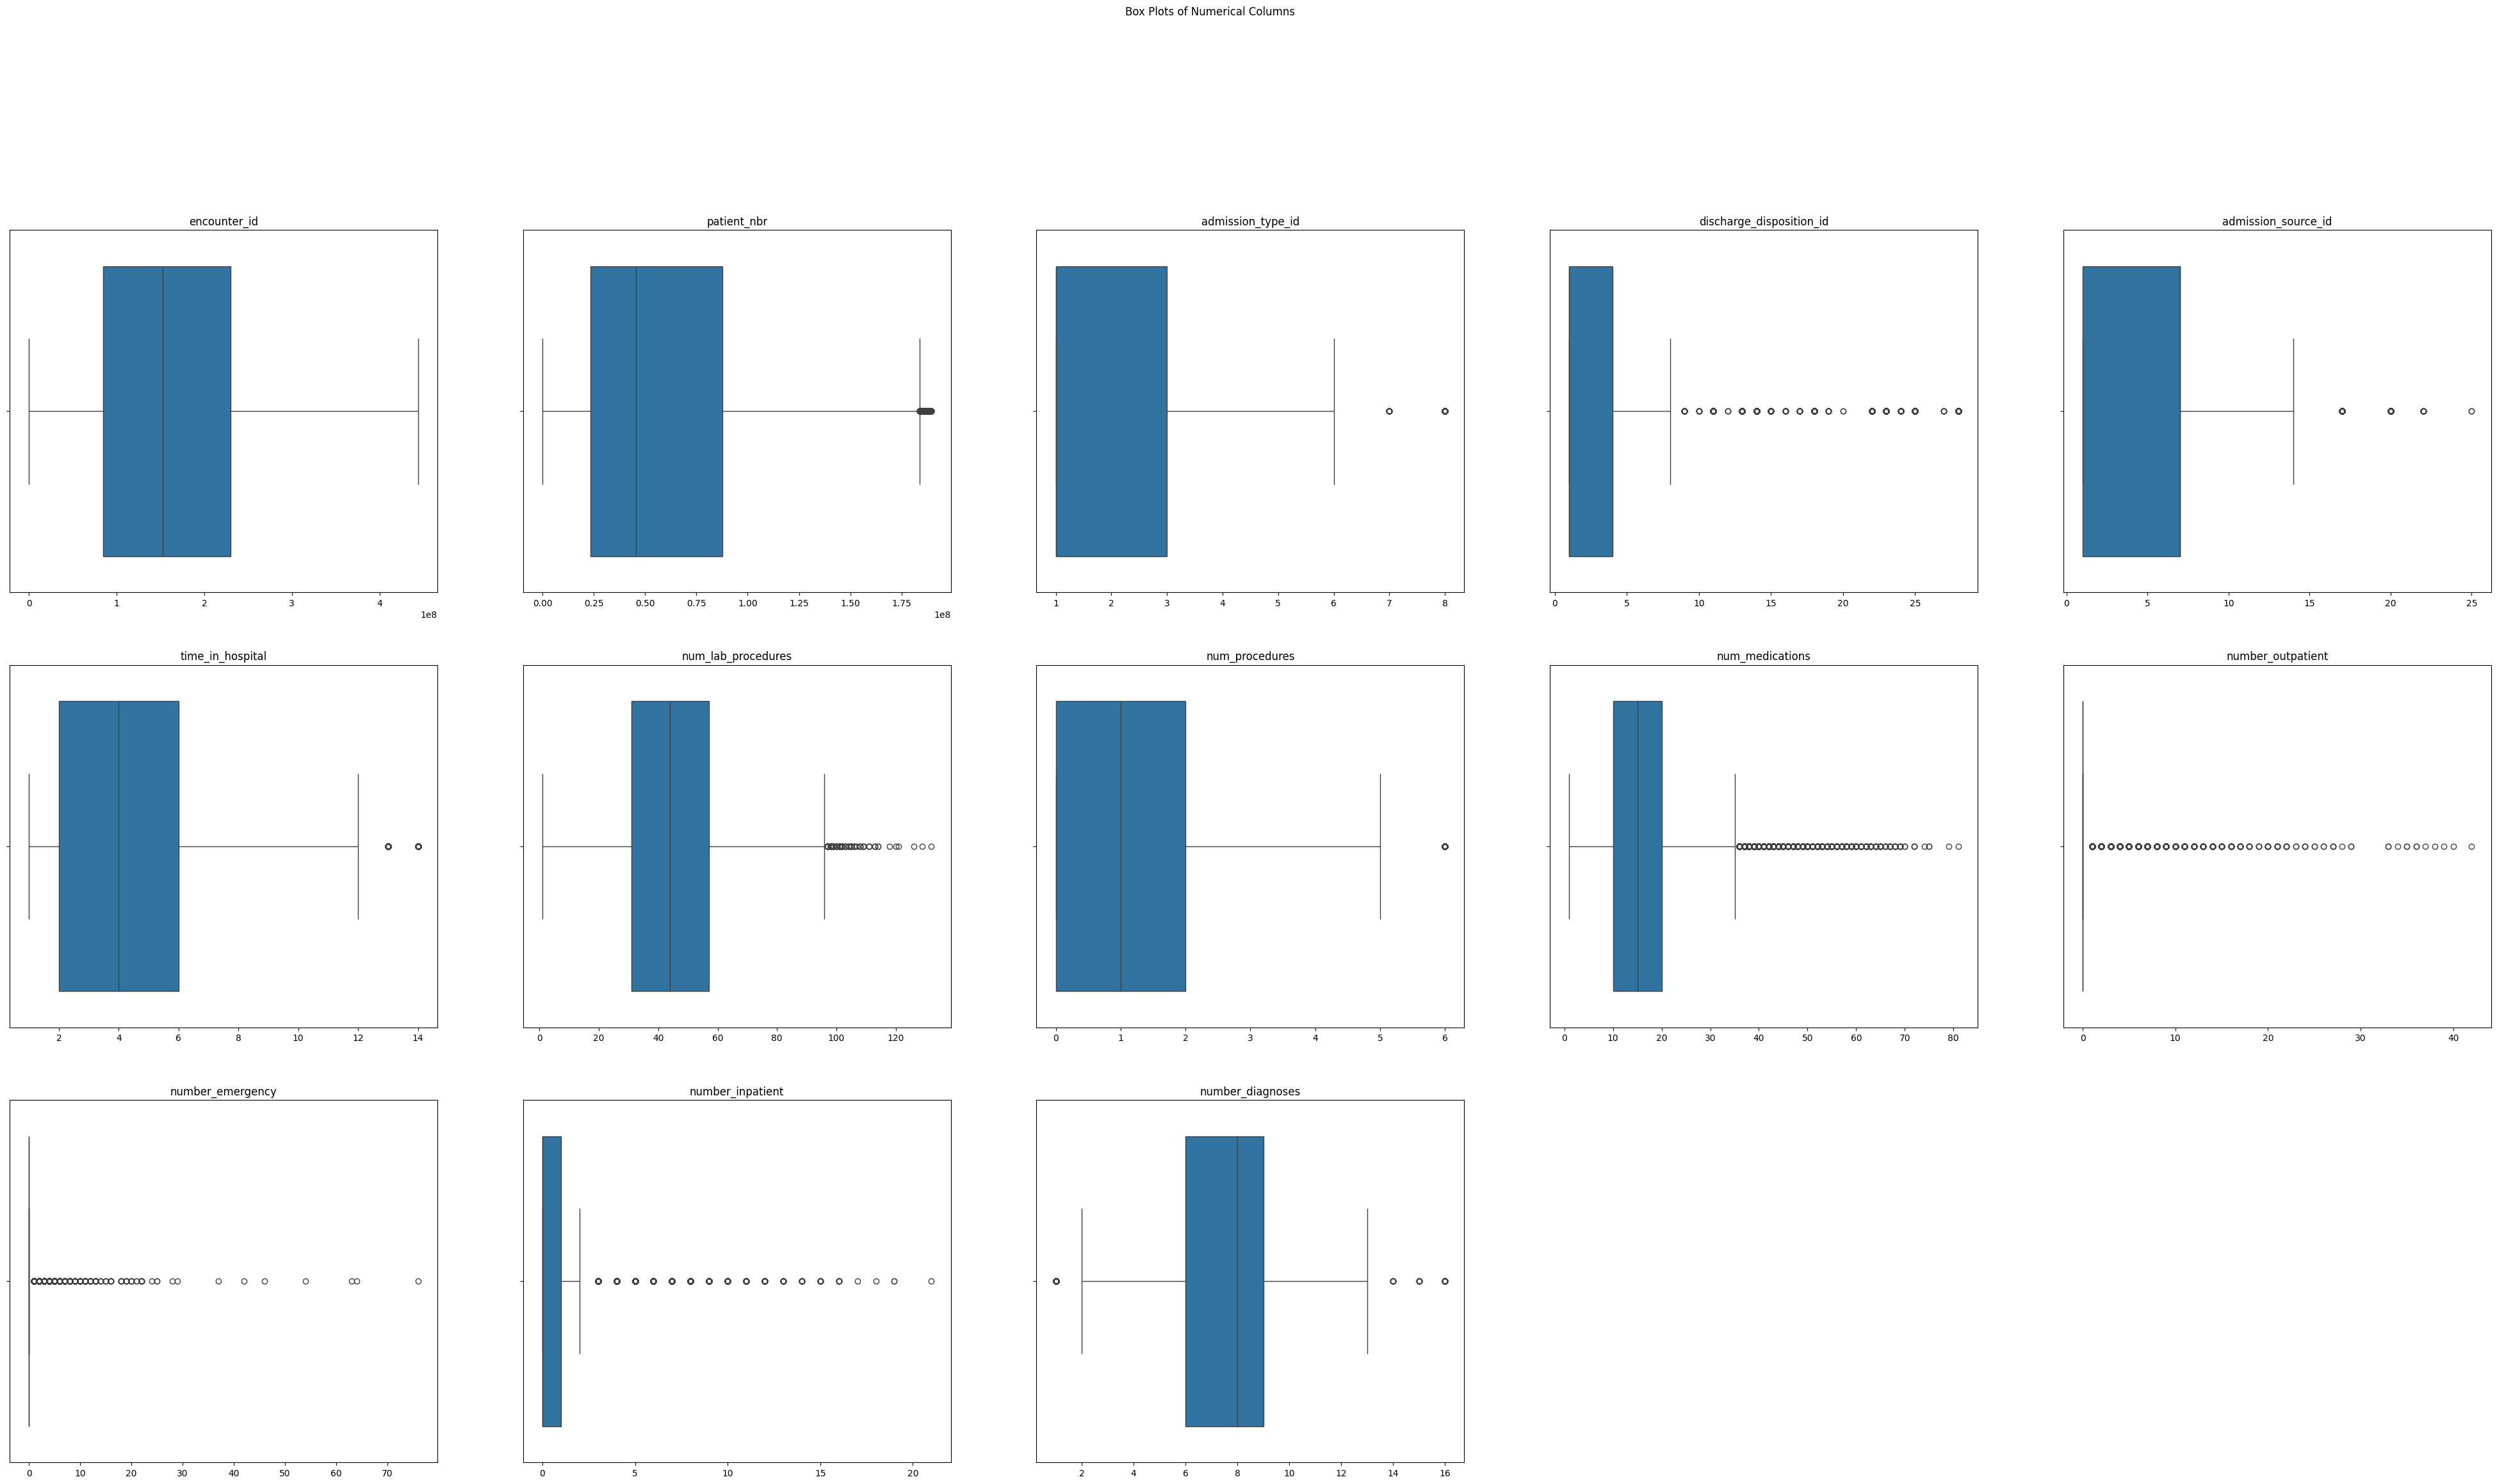

In [11]:
## box plot for outliers detection
plt.figure(figsize=(50,25))
plt.tight_layout()
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 5, i + 1)
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('Box Plots of Numerical Columns', y=1.02)
plt.show()
# Analysis of Numerical columns

#### Outliers and distribution of numerical columns are skewed, need to be treated accordingly. and shows multiple outliers. But most of them columns are identifiers so not much important for analysis.

Can drop the identifiers columns as they are not useful for analysis.Below are the numerical columns present in the dataset and their descriptions as understood from the report from ydata profiling.
### list of numerical columns
- encounter_id : Unique identifier for each hospital encounter.
- patient_nbr : Unique identifier for each patient.
- admission_type_id : Categorical code for type of admission.
- discharge_disposition_id : Categorical code for discharge status.
- adminission_source_id : Categorical code for admission source.
- time_in_hospital : Number of days the patient was hospitalized.
- num_lab_procedures : Number of lab tests performed during the stay.
- num_procedures : Number of procedures performed during the stay.
- num_medications : Number of distinct medications prescribed during the stay.
- number_outpatient : Number of outpatient visits in the year prior to admission.
- number_emergency : Number of emergency visits in the year prior to admission.
- number_inpatient : Number of inpatient visits in the year prior to admission.
- number_diagnoses : Number of diagnoses recorded during the stay.          

All these columns are of integer type (int64) and have no missing values. The identifiers (encounter_id, patient_nbr) are unique for each record. The other numerical columns provide quantitative information about the patient's hospital stay, treatments, and prior healthcare utilization. There are no duplicates or missing data in these numerical columns, making them reliable for further analysis.


4   admission_source_id       101766 non-null  int64
 5   time_in_hospital          101766 non-null  int64
 6   num_lab_procedures        101766 non-null  int64
 7   num_procedures            101766 non-null  int64
 8   num_medications           101766 non-null  int64
 9   number_outpatient         101766 non-null  int64
 10  number_emergency          101766 non-null  int64
 11  number_inpatient          101766 non-null  int64
 12  number_diagnoses 

In [12]:
data.time_in_hospital.head()

0    1
1    3
2    2
3    2
4    1
Name: time_in_hospital, dtype: int64

## Do attribute to id mapping for categorical columns
- **Admission Type**: `admission_type_id` → mapped to `admission_type_desc`  
- **Discharge Disposition**: `discharge_disposition_id` → mapped to `discharge_desc`  
- **Admission Source**: `admission_source_id` → mapped to `admission_source_desc`  

In [13]:
# map admission_type_id to admission_type_desc
admission_type_id = data.admission_type_id.unique()
admission_type_desc = data.admission_type_desc.unique()
admission_type_mapping = dict(zip(admission_type_id, admission_type_desc))
data['admission_type'] = data['admission_type_id'].map(admission_type_mapping)
data.drop(columns=['admission_type_id', 'admission_type_desc'], inplace=True)

In [14]:
# map discharge_disposition_id to discharge_desc
discharge_disposition_id = data.discharge_disposition_id.unique()
discharge_desc = data.discharge_desc.unique()
discharge_mapping = dict(zip(discharge_disposition_id, discharge_desc))
data['discharge_disposition'] = data['discharge_disposition_id'].map(discharge_mapping)
data.drop(columns=['discharge_disposition_id', 'discharge_desc'], inplace=True) 


In [15]:
# map admission_source_id to admission_source_desc
admission_source_id = data.admission_source_id.unique()
admission_source_desc = data.admission_source_desc.unique()
admission_source_mapping = dict(zip(admission_source_id, admission_source_desc))
data['admission_source'] = data['admission_source_id'].map(admission_source_mapping)
data.drop(columns=['admission_source_id', 'admission_source_desc'], inplace=True)

In [16]:
# check for NaN or ? missing values in categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", categorical_cols)
for col in categorical_cols:
    num_missing = data[col].isnull().sum() + (data[col] == '?').sum()
    if num_missing > 0:
        print(f"\t --> {col}: {num_missing} missing values")


Categorical columns: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type', 'discharge_disposition', 'admission_source']
	 --> race: 2273 missing values
	 --> weight: 98569 missing values
	 --> payer_code: 40256 missing values
	 --> medical_specialty: 49949 missing values
	 --> diag_1: 21 missing values
	 --> diag_2: 358 missing values
	 --> diag_3: 1423 missing values
	 --> max_glu_serum: 96420 missing values
	 --> A1Cresult: 84748 missing values
	 --> admission_type: 5291 mi

In [17]:
# checking column race
for col in categorical_cols:
    value_counts = data[col].value_counts(dropna=False)
    print(f"\nValue counts for column '{col}': \n{value_counts}\n")
    # relace ? or Nan with UNKNOWN
    data[col] = data[col].replace('?', 'UNKNOWN')
    data[col] = data[col].fillna('UNKNOWN')


Value counts for column 'race': 
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


Value counts for column 'gender': 
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


Value counts for column 'age': 
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


Value counts for column 'weight': 
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64


Value counts for column 'payer_code': 
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533


## Drop the rows where unknown count > 500 else keep it as it can be useful for analysis


In [18]:
# original shape before dropping rows
print("\nOriginal shape of the dataset before dropping rows with 'UNKNOWN':", data.shape)

for col in categorical_cols:
    count_unknown = (data[col] == 'UNKNOWN').sum()
    if count_unknown < 500:
        # drop the rows with UNKNOWN
        initial_shape = data.shape
        data = data[data[col] != 'UNKNOWN']
        if data.shape != initial_shape:
            print(f"Dropped {initial_shape[0] - data.shape[0]} rows with 'UNKNOWN' in column '{col}'. New shape: {data.shape}")

# print final shape of the dataset
print("\nFinal shape of the dataset after cleaning:", data.shape)


Original shape of the dataset before dropping rows with 'UNKNOWN': (101766, 50)
Dropped 21 rows with 'UNKNOWN' in column 'diag_1'. New shape: (101745, 50)
Dropped 357 rows with 'UNKNOWN' in column 'diag_2'. New shape: (101388, 50)

Final shape of the dataset after cleaning: (101388, 50)


In [19]:
# print value counts of categorical columns after cleaning
for col in categorical_cols:
    value_counts = data[col].value_counts(dropna=False)
    print(f"\nValue counts for column '{col}' after cleaning: \n{value_counts}\n")
# drop rows from gender where UNKNOWN/Invalid 
initial_shape = data.shape
data = data[data.gender != 'Unknown/Invalid']



Value counts for column 'race' after cleaning: 
race
Caucasian          75832
AfricanAmerican    19142
UNKNOWN             2249
Hispanic            2023
Other               1504
Asian                638
Name: count, dtype: int64


Value counts for column 'gender' after cleaning: 
gender
Female             54523
Male               46862
Unknown/Invalid        3
Name: count, dtype: int64


Value counts for column 'age' after cleaning: 
age
[70-80)     26029
[60-70)     22438
[50-60)     17231
[80-90)     17155
[40-50)      9648
[30-40)      3758
[90-100)     2789
[20-30)      1624
[10-20)       601
[0-10)        115
Name: count, dtype: int64


Value counts for column 'weight' after cleaning: 
weight
UNKNOWN      98203
[75-100)      1336
[50-75)        892
[100-125)      625
[125-150)      145
[25-50)         93
[0-25)          45
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64


Value counts for column 'payer_code' after cleaning: 
payer_code
UNKNOWN  

| Column                                                       | Cardinality           | Suggested Encoding                                           |
| ------------------------------------------------------------ | --------------------- | ------------------------------------------------------------ |
| `gender`, `change`, `diabetesMed`                            | Low (≤5)              | **Label encoding** (or even OHE if few total columns)        |
| `race`, `age`, `max_glu_serum`, `A1Cresult`, `insulin`       | Mid (5–10)            | **Label or frequency encoding**                              |
| `weight`, `payer_code`, `admission_type`, `admission_source` | Mid-High (10–20)      | **Frequency encoding**                                       |
| `medical_specialty`, `diag_1`, `diag_2`, `diag_3`            | High (70–790)         | **Target encoding** (with CV), or **hashing encoding**       |
| `medication columns` (`metformin`, `glipizide`, etc.)        | Mostly 3–4 categories | **Label encoding** (compact and safe for tree models)        |
| `discharge_disposition`                                      | High (25+)            | **Frequency encoding**, or **group rare categories** + label |


In [20]:
# find columns, if we have 2 unique values it goes for binary encoding else OHE
binary_encode_cols = []
ohe_cols = []
for col in categorical_cols:
    unique_vals = data[col].nunique()
    if unique_vals == 2:
        binary_encode_cols.append(col)
    else:
        ohe_cols.append(col)

print("Binary encoding columns:", binary_encode_cols)
high_cardinality_cols = [col for col in categorical_cols if data[col].nunique() > 10]
print("High cardinality columns (more than 10 unique values):", high_cardinality_cols)
# remove high cardinality columns from OHE list
ohe_cols = [col for col in ohe_cols if col not in high_cardinality_cols]
print("OHE columns after removing high cardinality columns:", ohe_cols)

Binary encoding columns: ['gender', 'acetohexamide', 'tolbutamide', 'troglitazone', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
High cardinality columns (more than 10 unique values): ['payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'discharge_disposition', 'admission_source']
OHE columns after removing high cardinality columns: ['race', 'age', 'weight', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'readmitted', 'admission_type']


In [21]:
# Binary Encoding using LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_encode_cols:
    # fit once on the entire column (converted to str)
    le.fit(data[col].astype(str))
    
    # get mapping: class label -> encoded integer
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Mapping for column '{col}': {mapping}")
    
    # transform entire column
    data[col] = le.transform(data[col].astype(str))

Mapping for column 'gender': {'Female': 0, 'Male': 1}
Mapping for column 'acetohexamide': {'No': 0, 'Steady': 1}
Mapping for column 'tolbutamide': {'No': 0, 'Steady': 1}
Mapping for column 'troglitazone': {'No': 0, 'Steady': 1}
Mapping for column 'glipizide-metformin': {'No': 0, 'Steady': 1}
Mapping for column 'glimepiride-pioglitazone': {'No': 0, 'Steady': 1}
Mapping for column 'metformin-rosiglitazone': {'No': 0, 'Steady': 1}
Mapping for column 'metformin-pioglitazone': {'No': 0, 'Steady': 1}
Mapping for column 'change': {'Ch': 0, 'No': 1}
Mapping for column 'diabetesMed': {'No': 0, 'Yes': 1}


In [22]:
# # #  OHE columns
data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)


In [23]:
def get_data_metadata(df):
    print("\nFinal shape of the dataset after encoding:", data.shape)
    print("Data Columns : ", data.columns.tolist())
    print("Data Types : ", data.dtypes)
    print("Size of data in memory (in MBs):", data.memory_usage(deep=True).sum() / (1024 * 1024)) 

In [24]:
## analysing high cardinality columns
for col in high_cardinality_cols:
    value_counts = data[col].value_counts(dropna=False)
    print(f"\nValue counts for high cardinality column '{col}': \n{value_counts}\n")


Value counts for high cardinality column 'payer_code': 
payer_code
UNKNOWN    40083
MC         32366
HM          6254
SP          4977
BC          4633
MD          3518
CP          2522
UN          2420
CM          1936
OG          1031
PO           590
DM           546
CH           146
WC           133
OT            95
MP            79
SI            55
FR             1
Name: count, dtype: int64


Value counts for high cardinality column 'medical_specialty': 
medical_specialty
UNKNOWN                             49841
InternalMedicine                    14572
Emergency/Trauma                     7541
Family/GeneralPractice               7407
Cardiology                           5346
                                    ...  
Speech                                  1
Pediatrics-InfectiousDiseases           1
Perinatology                            1
Neurophysiology                         1
Surgery-PlasticwithinHeadandNeck        1
Name: count, Length: 73, dtype: int64


Value counts fo

In [25]:
# strip alphabetic characters from the diag_1, diag_2, diag_3 columns and convert to numeric
for col in ['diag_1', 'diag_2', 'diag_3']:
    data[col] = data[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]
    data[col] = pd.to_numeric(data[col], errors='coerce')
    num_missing = data[col].isnull().sum()
    if num_missing > 0:
        print(f"Column '{col}' has {num_missing} missing values after conversion to numeric.")

Column 'diag_3' has 1144 missing values after conversion to numeric.


In [26]:
# imputing diag_3 missing values with median
median_diag_3 = data['diag_3'].median()
print(f"Median of 'diag_3' for imputation: {median_diag_3}")
data['diag_3'] = data['diag_3'].fillna(median_diag_3)
num_missing_diag_3 = data['diag_3'].isnull().sum()
if num_missing_diag_3 == 0:
    print("All missing values in 'diag_3' have been imputed.")

Median of 'diag_3' for imputation: 402.0
All missing values in 'diag_3' have been imputed.


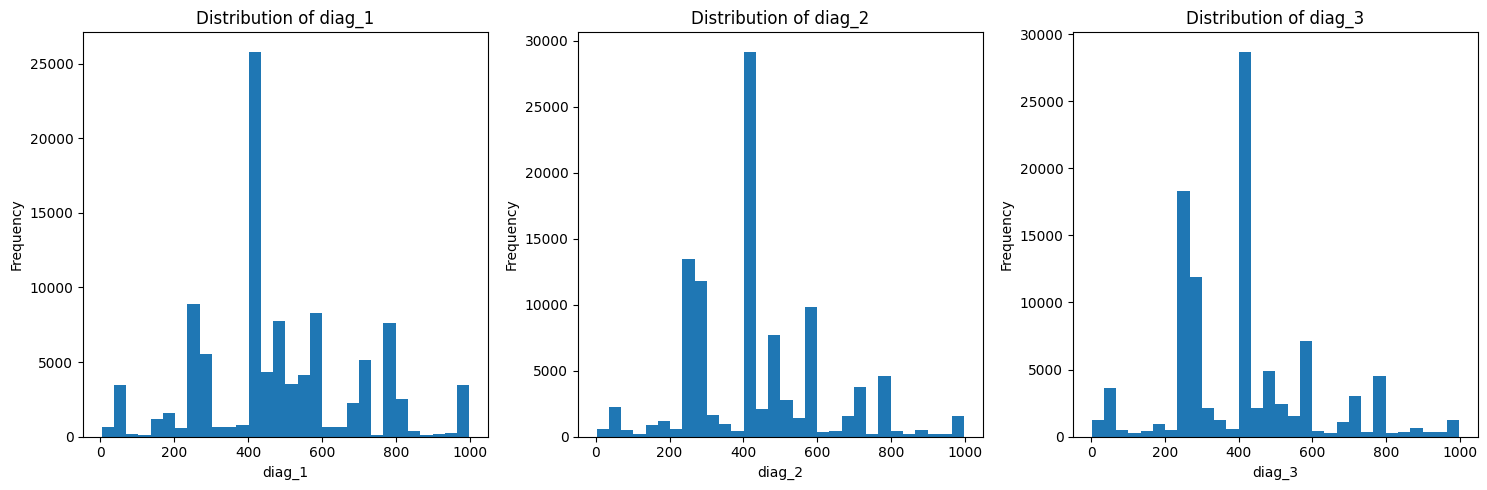

In [27]:
#plot diag_1 , diag_2 and diag_3 distribution
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
data.diag_1.plot(kind='hist', bins=30, title='Distribution of diag_1')
plt.xlabel('diag_1')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
data.diag_2.plot(kind='hist', bins=30, title='Distribution of diag_2')
plt.xlabel('diag_2')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
data.diag_3.plot(kind='hist', bins=30, title='Distribution of diag_3')
plt.xlabel('diag_3')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()  

In [28]:
# normalize diag_1, diag_2 and diag_3 using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['diag_1', 'diag_2', 'diag_3']] = scaler.fit_transform(data[['diag_1', 'diag_2', 'diag_3']])
print("\nFinal shape of the dataset after encoding:", data.shape)

# remove diag_1, diag_2 and diag_3 from high cardinality columns
high_cardinality_cols = [col for col in high_cardinality_cols if col not in ['diag_1', 'diag_2', 'diag_3']]
print("High cardinality columns after removing diag_1, diag_2, diag_3:", high_cardinality_cols)


Final shape of the dataset after encoding: (101385, 106)
High cardinality columns after removing diag_1, diag_2, diag_3: ['payer_code', 'medical_specialty', 'discharge_disposition', 'admission_source']


In [29]:
print("medical speciality value counts \n",data.medical_specialty.value_counts())
print("Payer code value count \n",data.payer_code.value_counts())
print("discharge_disposition value count \n",data.discharge_disposition.value_counts())
print("admission source value count \n",data.admission_source.value_counts())

medical speciality value counts 
 medical_specialty
UNKNOWN                             49841
InternalMedicine                    14572
Emergency/Trauma                     7541
Family/GeneralPractice               7407
Cardiology                           5346
                                    ...  
Speech                                  1
Pediatrics-InfectiousDiseases           1
Perinatology                            1
Neurophysiology                         1
Surgery-PlasticwithinHeadandNeck        1
Name: count, Length: 73, dtype: int64
Payer code value count 
 payer_code
UNKNOWN    40083
MC         32366
HM          6254
SP          4977
BC          4633
MD          3518
CP          2522
UN          2420
CM          1936
OG          1031
PO           590
DM           546
CH           146
WC           133
OT            95
MP            79
SI            55
FR             1
Name: count, dtype: int64
discharge_disposition value count 
 discharge_disposition
Discharged to home    

In [30]:
def group_rare_categories(col, threshold=100, unknown_values=['UNKNOWN', 'Not Mapped', 'Not Available']):
    """Group categories with frequency < threshold as 'Other' except unknown-like categories."""
    value_counts = data[col].value_counts()
    rare = value_counts[value_counts < threshold].index
    # Replace rare categories with 'Other' but keep unknowns intact
    def replace_func(x):
        if x in unknown_values:
            return x
        elif x in rare:
            return 'Other'
        else:
            return x
    return data[col].apply(replace_func)


In [31]:
# 1. medical_specialty
data['medical_specialty'] = group_rare_categories('medical_specialty', threshold=100)
# Encode with label encoding

le_med_spec = LabelEncoder()
data['medical_specialty_enc'] = le_med_spec.fit_transform(data['medical_specialty'].astype(str))

# 2. payer_code
data['payer_code'] = group_rare_categories('payer_code', threshold=100)
le_payer = LabelEncoder()
data['payer_code_enc'] = le_payer.fit_transform(data['payer_code'].astype(str))

# 3. discharge_disposition
data['discharge_disposition'] = group_rare_categories('discharge_disposition', threshold=100, unknown_values=['UNKNOWN', 'Not Mapped'])
le_discharge = LabelEncoder()
data['discharge_disposition_enc'] = le_discharge.fit_transform(data['discharge_disposition'].astype(str))

# 4. admission_source
data['admission_source'] = group_rare_categories('admission_source', threshold=100,unknown_values=['UNKNOWN', 'Not Mapped', 'Not Available'])
le_admission = LabelEncoder()
data['admission_source_enc'] = le_admission.fit_transform(data['admission_source'].astype(str))



In [32]:

# Check mapping for example
print("medical_specialty mapping:", dict(zip(le_med_spec.classes_, le_med_spec.transform(le_med_spec.classes_))))
print("payer_code mapping:", dict(zip(le_payer.classes_, le_payer.transform(le_payer.classes_))))
print("discharge_disposition mapping:", dict(zip(le_discharge.classes_, le_discharge.transform(le_discharge.classes_))))
print("admission_source mapping:", dict(zip(le_admission.classes_, le_admission.transform(le_admission.classes_))))

medical_specialty mapping: {'Cardiology': 0, 'Emergency/Trauma': 1, 'Endocrinology': 2, 'Family/GeneralPractice': 3, 'Gastroenterology': 4, 'Hematology/Oncology': 5, 'InternalMedicine': 6, 'Nephrology': 7, 'Neurology': 8, 'ObstetricsandGynecology': 9, 'Oncology': 10, 'Orthopedics': 11, 'Orthopedics-Reconstructive': 12, 'Other': 13, 'Otolaryngology': 14, 'Pediatrics': 15, 'PhysicalMedicineandRehabilitation': 16, 'Podiatry': 17, 'Psychiatry': 18, 'Psychology': 19, 'Pulmonology': 20, 'Radiologist': 21, 'Surgery-Cardiovascular/Thoracic': 22, 'Surgery-General': 23, 'Surgery-Neuro': 24, 'Surgery-Thoracic': 25, 'Surgery-Vascular': 26, 'UNKNOWN': 27, 'Urology': 28}
payer_code mapping: {'BC': 0, 'CH': 1, 'CM': 2, 'CP': 3, 'DM': 4, 'HM': 5, 'MC': 6, 'MD': 7, 'OG': 8, 'Other': 9, 'PO': 10, 'SP': 11, 'UN': 12, 'UNKNOWN': 13, 'WC': 14}
discharge_disposition mapping: {'Discharged to home': 0, 'Discharged/transferred to ICF': 1, 'Discharged/transferred to SNF': 2, 'Discharged/transferred to a long te

In [33]:
data.drop(columns=['medical_specialty', 'payer_code', 'discharge_disposition', 'admission_source'], inplace=True)
get_data_metadata(data)


Final shape of the dataset after encoding: (101385, 106)
Data Columns :  ['encounter_id', 'patient_nbr', 'gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'acetohexamide', 'tolbutamide', 'troglitazone', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_UNKNOWN', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'weight_UNKNOWN', 'weight_[0-25)', 'weight_[100-125)', 'weight_[125-150)', 'weight_[150-175)', 'weight_[175-200)', 'weight_[25-50)', 'weight_[50-75)', 'weight_[75-100)', 'max_glu_serum_>300', 'max_glu_serum_Norm', 'max_glu_serum_UNKNOWN', 'A1Cresult_>8', 'A1Cresult_Norm', 'A1Cresult_UNKNOWN', 'metform

In [38]:
# group data by data types
for col in data.dtypes.unique():
    cols = data.select_dtypes(include=[col]).columns.tolist()
    print(f"Columns of type '{col}': {cols}\n")

Columns of type 'int64': ['encounter_id', 'patient_nbr', 'gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'acetohexamide', 'tolbutamide', 'troglitazone', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'medical_specialty_enc', 'payer_code_enc', 'discharge_disposition_enc', 'admission_source_enc']

Columns of type 'float64': ['diag_1', 'diag_2', 'diag_3']

Columns of type 'bool': ['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_UNKNOWN', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'weight_UNKNOWN', 'weight_[0-25)', 'weight_[100-125)', 'weight_[125-150)', 'weight_[150-175)', 'weight_[175-200)', 'weight_[25-50)', 'weight_[50-75)', 'weight_[75-100)', 'max_glu_serum_>300', 'max_glu

In [49]:
# generate a cleaned data profiling report
profile = ProfileReport(data, title="Diabetes Dataset Cleaned - EDA Report",  correlations={"pearson": {"calculate": True}})
profile.to_file("diabetes_data_eda_cleaned_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 106/106 [00:00<00:00, 108.64it/s]
/home/swapnil/COURSE-PROJECTS/DATA-SCIENCE-PRACTICE/venv/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
/home/swapnil/COURSE-PROJECTS/DATA-SCIENCE-PRACTICE/venv/lib/python3.12/site-packages/ydata_profiling/model/pandas/duplicates_pandas.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index(name=duplicates_key)
/home/swapnil/COURSE-PROJECTS/DATA-SCIENCE-

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

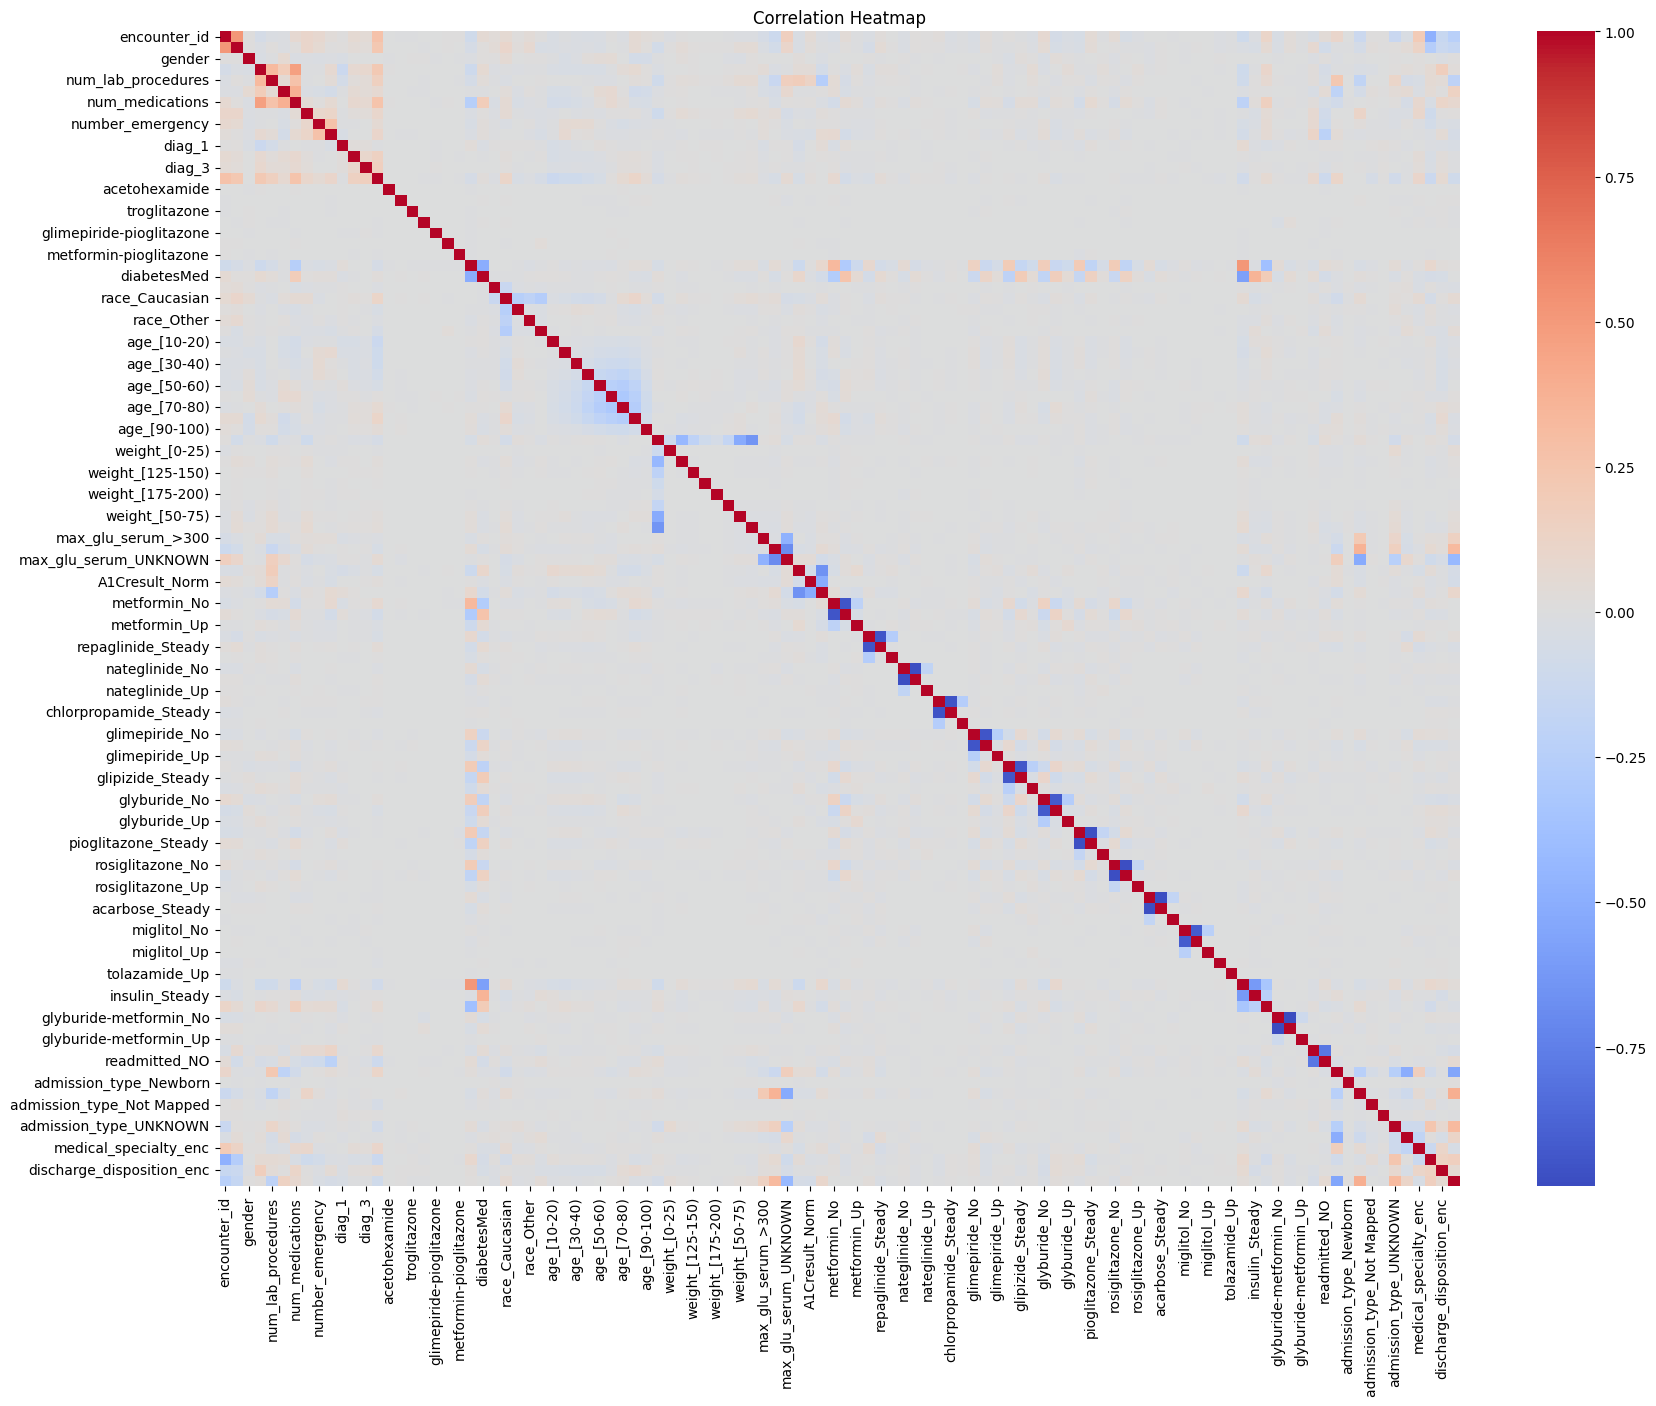

In [43]:
# generating heatmap
plt.figure(figsize=(20,15))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Heatmap')
plt.show()


In [50]:
## saving cleaned data
data.to_csv('diabetes_data_cleaned.csv', index=False)

## Summarize insights


### 1. **Dataset Overview**
- The dataset contains 101,766 hospital admissions for diabetic patients, with 53 variables.
- Features include demographics, admission/discharge details, diagnoses, lab results, medications, and outcomes.
- The primary goal is to predict readmission within 30 days.

### 2. **Initial Data Inspection**
- Loaded the dataset and checked its shape, column names, and data types.
- Used `.info()` and `.describe()` to understand variable types and basic statistics.
- Identified that missing values are sometimes coded as `"?"` instead of `NaN`.

### 3. **Data Quality Checks**
- Checked for and removed duplicate rows (none found).
- Summarized missing values and unique values per column.
- Noted that some columns (e.g., `age`) are stored as objects but represent numeric or ordinal data.

### 4. **Numerical Columns Analysis**
- Identified 13 numerical columns, including identifiers and clinical measures.
- All numerical columns are complete (no missing values).
- Plotted histograms and boxplots to visualize distributions and detect outliers.
- Observed that some columns (e.g., `time_in_hospital`, `num_lab_procedures`) are skewed and contain outliers.
- Decided to drop identifier columns (`encounter_id`, `patient_nbr`) from further analysis as they do not provide analytical value.

### 5. **Categorical Columns Handling**
- Mapped categorical code columns (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) to their descriptive labels for interpretability.
- Checked for missing values and replaced `"?"` and `NaN` with `"UNKNOWN"` in categorical columns.
- Dropped rows where the count of `"UNKNOWN"` in a column was less than 500, to avoid bias from rare missingness.
- For columns with high cardinality (many unique values), grouped rare categories as `"Other"` to reduce dimensionality.

### 6. **Encoding Categorical Variables**
- Used label encoding for binary columns and columns with low cardinality.
- Applied one-hot encoding (OHE) for columns with moderate cardinality.
- For high-cardinality columns (e.g., `medical_specialty`, `payer_code`), grouped rare categories and then label-encoded.
- Converted diagnosis columns (`diag_1`, `diag_2`, `diag_3`) to numeric, handled missing values, and normalized them.

### 7. **Data Profiling and Visualization**
- Generated automated EDA reports using `ydata_profiling` before and after cleaning.
- Visualized distributions, outliers, and correlations using histograms, boxplots, and heatmaps.

### 8. **Summary of Data After Cleaning**
- The cleaned dataset has no duplicates and minimal missing values.
- All categorical codes are mapped or encoded for analysis.
- Outliers and skewness in clinical measures are noted for further modeling considerations.
- The dataset is now suitable for statistical analysis and machine learning.

---

### **Why These Steps Were Taken**

- **Data Quality:** Ensuring no duplicates or unhandled missing values improves reliability.
- **Interpretability:** Mapping codes to descriptions and encoding categorical variables makes the data usable for analysis and modeling.
- **Dimensionality Reduction:** Grouping rare categories prevents overfitting and reduces noise.
- **Visualization:** Helps in understanding distributions, detecting outliers, and identifying relationships.
- **Reproducibility:** All steps are coded and documented for consistent results.

---

### **Key Insights**

- The dataset is large, diverse, and mostly clean, but contains some skewed distributions and outliers.
- Many features are categorical codes that require mapping for meaningful analysis.
- Proper encoding and handling of rare categories are crucial for robust modeling.
- The data is now ready for advanced EDA, feature engineering, and predictive modeling.
